## Student Performance Analysis

This notebook performs a comprehensive statistical and predictive analysis on a dataset of student performance, investigating key factors that correlate with academic success.

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")

Libraries loaded.


### 1. Data Ingestion

We load the raw Student Performance dataset (`student-mat.csv`) using a semicolon delimiter, inspect its basic shape, and preview the first few records.

In [ ]:
from google.colab import files
import io

# Re-load the dataset with the correct semicolon separator
df = pd.read_csv('/content/student-mat.csv', sep=';')

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 2. General Data Exploration & Cleaning

Here we programmatically inspect columns, count non-null attributes to verify completeness, search for duplicate rows, and generate summary statistics.

In [ ]:
# Inspect data types, missing values, and general info
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values Summary ===")
print(df.isnull().sum())

print("\n=== Numerical Summary Statistics ===")
display(df.describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    o

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### 3. Outlier and Distribution Checks

We visualize critical numerical distributions (such as `absences`, grades, `age`, and `studytime`) with boxplots to detect any anomalous values or extreme outliers.

Number of duplicate rows: 0


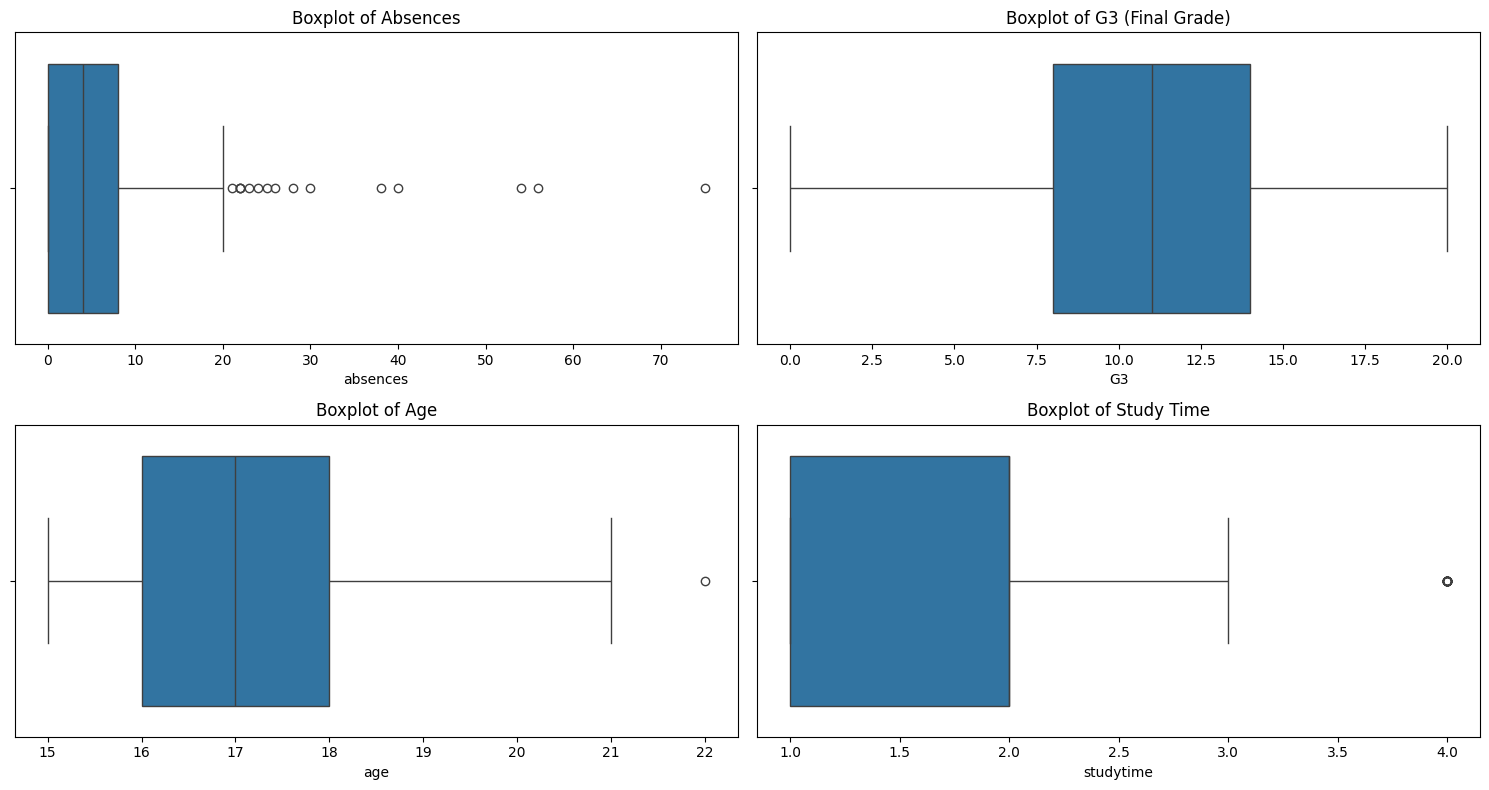

In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Visualize outliers in numerical columns using boxplots
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x=df['absences'])
plt.title('Boxplot of Absences')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['G3'])
plt.title('Boxplot of G3 (Final Grade)')

plt.subplot(2, 2, 3)
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['studytime'])
plt.title('Boxplot of Study Time')

plt.tight_layout()
plt.show()

### 4. Feature Engineering and Data Standardization

In this step, we minimize outlier distortion by capping student absences. We then engineer custom features (`total_grades` and `study_to_free_ratio`), map binary columns, apply one-hot encoding, and standardize continuous predictors using `StandardScaler`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create a working copy of the dataframe
df_preprocessed = df.copy()

# 1. Handling outliers for 'absences'
q_95 = df_preprocessed['absences'].quantile(0.95)
df_preprocessed['absences'] = np.where(df_preprocessed['absences'] > q_95, q_95, df_preprocessed['absences'])

# 2. Feature Engineering (Only past grades are aggregated to avoid data leakage with G3)
df_preprocessed['past_grades'] = df_preprocessed['G1'] + df_preprocessed['G2']
df_preprocessed['study_to_free_ratio'] = df_preprocessed['studytime'] / (df_preprocessed['freetime'] + 1e-5)

# 3. Categorical Encoding
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
for col in binary_cols:
    df_preprocessed[col] = df_preprocessed[col].map({'yes': 1, 'no': 0})

df_preprocessed['school'] = df_preprocessed['school'].map({'GP': 1, 'MS': 0})
df_preprocessed['sex'] = df_preprocessed['sex'].map({'F': 1, 'M': 0})
df_preprocessed['address'] = df_preprocessed['address'].map({'U': 1, 'R': 0})
df_preprocessed['famsize'] = df_preprocessed['famsize'].map({'GT3': 1, 'LE3': 0})
df_preprocessed['Pstatus'] = df_preprocessed['Pstatus'].map({'T': 1, 'A': 0})

# One-hot encoding for multi-class variables with explicit integer casting
multi_class_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_preprocessed = pd.get_dummies(df_preprocessed, columns=multi_class_cols, drop_first=True, dtype=int)

# 4. Separate target variable (G3) from features
X = df_preprocessed.drop(columns=['G3'])
y = df_preprocessed['G3']

# 5. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Feature scaling (fit on Train, transform on Test)
scaler = StandardScaler()
num_features = ['age', 'absences', 'G1', 'G2', 'past_grades', 'study_to_free_ratio']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Preprocessing and train/test split completed successfully!")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Preprocessing and train/test split completed successfully!
X_train shape: (316, 43), X_test shape: (79, 43)


In [ ]:
# from sklearn.preprocessing import StandardScaler

# # Create a working copy of the dataframe
# df_preprocessed = df.copy()

# # 1. Outlier Handling: Cap 'absences' at the 95th percentile
# q_95 = df_preprocessed['absences'].quantile(0.95)
# df_preprocessed['absences'] = np.where(df_preprocessed['absences'] > q_95, q_95, df_preprocessed['absences'])

# # 2. Feature Engineering: Create meaningful combinations
# df_preprocessed['total_grades'] = df_preprocessed['G1'] + df_preprocessed['G2'] + df_preprocessed['G3']
# df_preprocessed['study_to_free_ratio'] = df_preprocessed['studytime'] / (df_preprocessed['freetime'] + 1e-5)

# # 3. Categorical Encoding
# # Encode binary categorical columns (yes/no -> 1/0)
# binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
# for col in binary_cols:
#     df_preprocessed[col] = df_preprocessed[col].map({'yes': 1, 'no': 0})

# # Encode other binary columns
# df_preprocessed['school'] = df_preprocessed['school'].map({'GP': 1, 'MS': 0})
# df_preprocessed['sex'] = df_preprocessed['sex'].map({'F': 1, 'M': 0})
# df_preprocessed['address'] = df_preprocessed['address'].map({'U': 1, 'R': 0})
# df_preprocessed['famsize'] = df_preprocessed['famsize'].map({'GT3': 1, 'LE3': 0})
# df_preprocessed['Pstatus'] = df_preprocessed['Pstatus'].map({'T': 1, 'A': 0})

# # One-hot encode multi-class columns
# multi_class_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
# df_preprocessed = pd.get_dummies(df_preprocessed, columns=multi_class_cols, drop_first=True)

# # 4. Standardize numerical features
# scaler = StandardScaler()
# num_features = ['age', 'absences', 'G1', 'G2', 'G3', 'total_grades', 'study_to_free_ratio']
# df_preprocessed[num_features] = scaler.fit_transform(df_preprocessed[num_features])

# print("Preprocessing completed successfully!")
# print(f"Preprocessed dataset shape: {df_preprocessed.shape}")
# display(df_preprocessed.head())

### 5. Exploratory Data Visualization

We plot the frequency distributions of the targets alongside a comprehensive correlation matrix heatmap to visually evaluate the connections among demographic and behavioral variables.

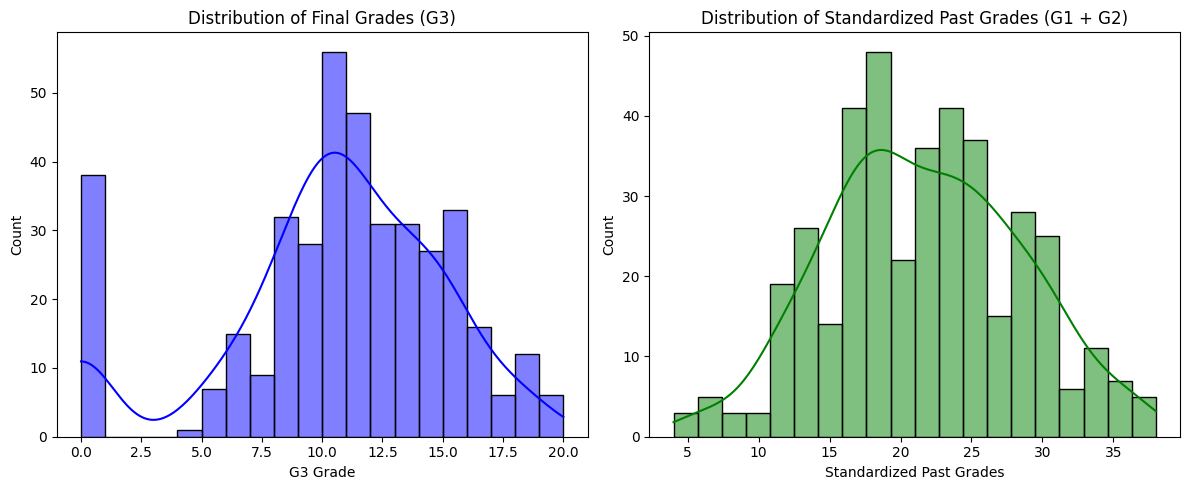

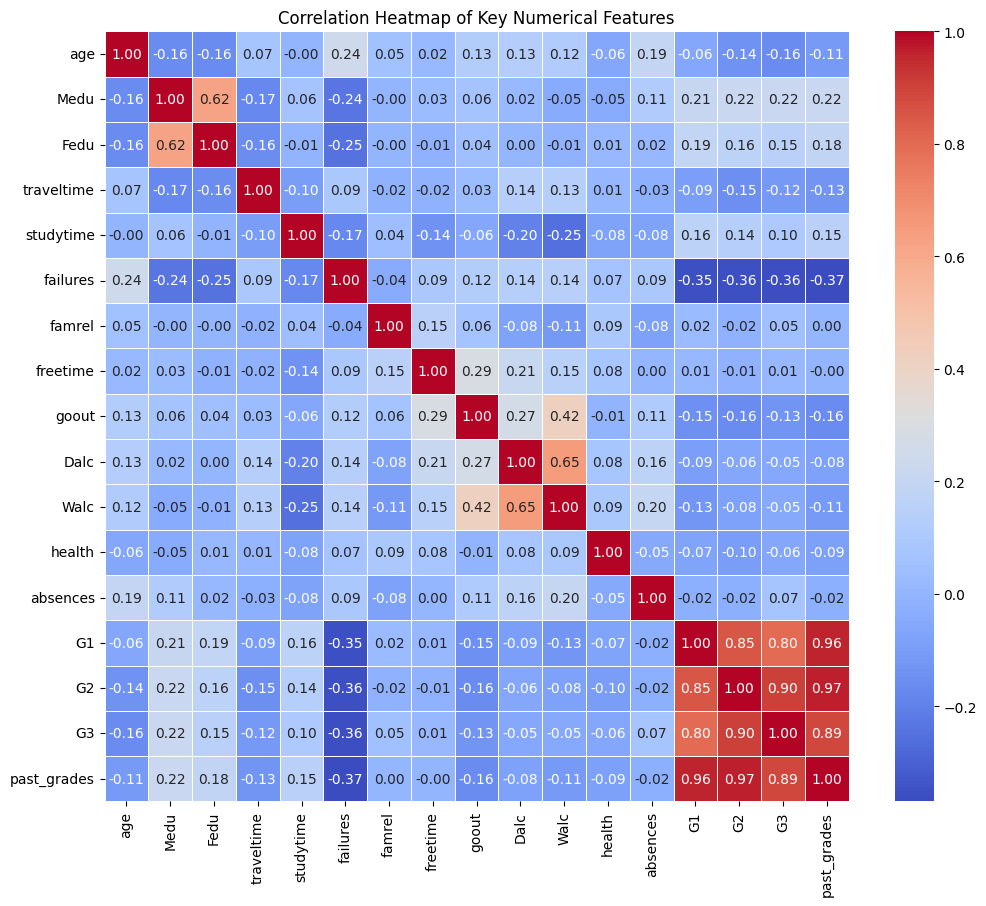

In [ ]:
# 1. Visualize the distribution of target variable and historical grades
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['G3'], kde=True, color='blue', bins=20)
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('G3 Grade')

plt.subplot(1, 2, 2)
# Using past_grades (G1 + G2) instead of total_grades to avoid data leakage
sns.histplot(df_preprocessed['past_grades'], kde=True, color='green', bins=20)
plt.title('Distribution of Standardized Past Grades (G1 + G2)')
plt.xlabel('Standardized Past Grades')

plt.tight_layout()
plt.show()

# 2. Correlation Matrix Heatmap of key numerical features
plt.figure(figsize=(12, 10))
key_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                'absences', 'G1', 'G2', 'G3', 'past_grades']

corr_matrix = df_preprocessed[key_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.show()

In [ ]:
# # 1. Visualize the distribution of total grades
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# sns.histplot(df['G3'], kde=True, color='blue', bins=20)
# plt.title('Distribution of Final Grades (G3)')
# plt.xlabel('G3 Grade')

# plt.subplot(1, 2, 2)
# sns.histplot(df_preprocessed['total_grades'], kde=True, color='green', bins=20)
# plt.title('Distribution of Standardized Total Grades (G1 + G2 + G3)')
# plt.xlabel('Standardized Total Grade')
# plt.tight_layout()
# plt.show()

# # 2. Correlation Matrix Heatmap of major variables (using df_preprocessed where 'total_grades' exists)
# plt.figure(figsize=(12, 10))
# key_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
#                 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
#                 'absences', 'G1', 'G2', 'G3', 'total_grades']
# corr_matrix = df_preprocessed[key_features].corr()
# sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
# plt.title('Correlation Heatmap of Key Numerical Features')
# plt.show()

### 6. Statistical Hypothesis Testing

We perform three formal statistical tests to validate patterns in the population:
1. **One-Sample t-test**: Compares the mean final grade against a target baseline of $10.0$.
2. **Two-Sample Independent t-test**: Investigates differences in academic outcomes between urban and rural students.
3. **Chi-Square Test**: Examines independence between student desire for higher education and romantic status.

In [ ]:
# Clean string formatting issues if present in the raw column names/values
df.columns = df.columns.str.strip()
for col in ['G1', 'G2', 'G3']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

alpha = 0.05

print("=== HYPOTHESIS TEST 1: One-Sample t-test ===")
# Null Hypothesis (H0): Mean G3 grade of students is equal to 10.0
# Alternative Hypothesis (H1): Mean G3 grade of students is not equal to 10.0
population_mean = 10.0
t_stat_1, p_val_1 = stats.ttest_1samp(df['G3'].dropna(), population_mean)

print(f"Sample Mean: {df['G3'].mean():.4f}")
print(f"t-statistic: {t_stat_1:.4f}")
print(f"p-value: {p_val_1:.4e}")
if p_val_1 < alpha:
    print("Decision: Reject the Null Hypothesis (H0). The mean grade is significantly different from 10.0.")
else:
    print("Decision: Do not Reject the Null Hypothesis (H0). There is no significant difference from 10.0.")

print("\n=== HYPOTHESIS TEST 2: Two-Sample t-test (Welch's t-test) ===")
# Null Hypothesis (H0): Mean G3 grade of urban students is equal to rural students
# Alternative Hypothesis (H1): Mean G3 grade of urban students is different from rural students
urban_grades = df[df['address'].str.strip() == 'U']['G3'].dropna()
rural_grades = df[df['address'].str.strip() == 'R']['G3'].dropna()
t_stat_2, p_val_2 = stats.ttest_ind(urban_grades, rural_grades, equal_var=False)

print(f"Urban Mean Grade: {urban_grades.mean():.4f}, Rural Mean Grade: {rural_grades.mean():.4f}")
print(f"t-statistic: {t_stat_2:.4f}")
print(f"p-value: {p_val_2:.4f}")
if p_val_2 < alpha:
    print("Decision: Reject the Null Hypothesis (H0). Urban and rural students have significantly different grades.")
else:
    print("Decision: Do not Reject the Null Hypothesis (H0). There is no significant difference in grades between urban and rural students.")

print("\n=== HYPOTHESIS TEST 3: Chi-Square Test of Independence ===")
# Null Hypothesis (H0): Wanting higher education and romantic status are independent
# Alternative Hypothesis (H1): Wanting higher education and romantic status are dependent
contingency_table = pd.crosstab(df['higher'], df['romantic'])
print("Contingency Table:")
print(contingency_table)

chi2_stat, p_val_3, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val_3:.4f}")
if p_val_3 < alpha:
    print("Decision: Reject the Null Hypothesis (H0). There is a significant relationship between wanting higher education and romantic status.")
else:
    print("Decision: Do not Reject the Null Hypothesis (H0). Wanting higher education and romantic status are independent.")

=== HYPOTHESIS TEST 1: One-Sample t-test ===
Sample Mean: 10.4152
t-statistic: 1.8011
p-value: 7.2448e-02
Decision: Do not Reject the Null Hypothesis (H0). There is no significant difference from 10.0.

=== HYPOTHESIS TEST 2: Two-Sample t-test (Welch's t-test) ===
Urban Mean Grade: 10.6743, Rural Mean Grade: 9.5114
t-statistic: 2.1101
p-value: 0.0366
Decision: Reject the Null Hypothesis (H0). Urban and rural students have significantly different grades.

=== HYPOTHESIS TEST 3: Chi-Square Test of Independence ===
Contingency Table:
romantic   no  yes
higher            
no          9   11
yes       254  121

Chi-square Statistic: 3.4476
p-value: 0.0633
Decision: Do not Reject the Null Hypothesis (H0). Wanting higher education and romantic status are independent.


In [ ]:
# import scipy.stats as stats

# print("=== HYPOTHESIS TEST 1: One-Sample t-test ===")
# # Null Hypothesis (H0): Mean G3 grade of students is equal to 10.0
# # Alternative Hypothesis (H1): Mean G3 grade of students is not equal to 10.0
# alpha = 0.05
# population_mean = 10.0
# t_stat, p_val_1 = stats.ttest_1samp(df['G3'], population_mean)

# print(f"Sample Mean: {df['G3'].mean():.4f}")
# print(f"t-statistic: {t_stat:.4f}")
# print(f"p-value: {p_val_1:.4e}")
# if p_val_1 < alpha:
#     print("Decision: Reject the Null Hypothesis (H0). The mean grade is significantly different from 10.0.")
# else:
#     print("Decision: Do not Reject the Null Hypothesis (H0). There is no significant difference from 10.0.")

# print("\n=== HYPOTHESIS TEST 2: Two-Sample t-test ===")
# # Null Hypothesis (H0): Mean G3 grade of urban students is equal to rural students
# # Alternative Hypothesis (H1): Mean G3 grade of urban students is different from rural students
# urban_grades = df[df['address'] == 'U']['G3']
# rural_grades = df[df['address'] == 'R']['G3']
# t_stat_2, p_val_2 = stats.ttest_ind(urban_grades, rural_grades, equal_var=False)

# print(f"Urban Mean Grade: {urban_grades.mean():.4f}, Rural Mean Grade: {rural_grades.mean():.4f}")
# print(f"t-statistic: {t_stat_2:.4f}")
# print(f"p-value: {p_val_2:.4f}")
# if p_val_2 < alpha:
#     print("Decision: Reject the Null Hypothesis (H0). Urban and rural students have significantly different grades.")
# else:
#     print("Decision: Do not Reject the Null Hypothesis (H0). There is no significant difference in grades between urban and rural students.")

# print("\n=== HYPOTHESIS TEST 3: Chi-Square Test of Independence ===")
# # Null Hypothesis (H0): Wanting higher education and romantic status are independent
# # Alternative Hypothesis (H1): Wanting higher education and romantic status are dependent
# contingency_table = pd.crosstab(df['higher'], df['romantic'])
# print("Contingency Table:")
# print(contingency_table)

# chi2_stat, p_val_3, dof, expected = stats.chi2_contingency(contingency_table)
# print(f"\nChi-square Statistic: {chi2_stat:.4f}")
# print(f"p-value: {p_val_3:.4f}")
# if p_val_3 < alpha:
#     print("Decision: Reject the Null Hypothesis (H0). There is a significant relationship between wanting higher education and romantic status.")
# else:
#     print("Decision: Do not Reject the Null Hypothesis (H0). Wanting higher education and romantic status are independent.")

### 7. Multiple Linear Regression

Using Ordinary Least Squares (OLS), we fit a Multiple Linear Regression model on a training set to quantify the strength of grade predictors and run standard diagnostic and predictive tests.

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Prepare features and target
# Target variable y remains on its original scale (0 to 20)
# X comes from the corrected preprocessed step (where Train/Test split was executed)
X_train_const = sm.add_constant(X_train).astype(float)
X_test_const = sm.add_constant(X_test).astype(float)

# 2. Fit Multiple Linear Regression (Ordinary Least Squares)
ols_model = sm.OLS(y_train, X_train_const).fit()
print("=== OLS Regression Summary (Training Set) ===")
print(ols_model.summary())

# 3. Predict on Test Set and Evaluate Metrics
y_pred = ols_model.predict(X_test_const)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100
test_r2 = r2_score(y_test, y_pred)

print("\n=== Model Performance Metrics (Test Set) ===")
print(f"Mean Absolute Error (MAE): {mae:.4f} grade points")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} grade points")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Test Set R-squared (R2): {test_r2:.4f}")

# 4. Mock Prediction Demonstration
mock_sample = X_test_const.iloc[0:1]
actual_value = y_test.iloc[0]
predicted_value = ols_model.predict(mock_sample).iloc[0]

print("\n=== Sample Prediction Demonstration ===")
print(f"Predicted G3 Grade: {predicted_value:.2f} / 20")
print(f"Actual G3 Grade: {actual_value:.2f} / 20")
print(f"Absolute Error: {abs(actual_value - predicted_value):.2f} grade points")

=== OLS Regression Summary (Training Set) ===
                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     44.65
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           3.08e-99
Time:                        11:21:23   Log-Likelihood:                -603.51
No. Observations:                 316   AIC:                             1293.
Df Residuals:                     273   BIC:                             1455.
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

/tmp/ipykernel_2384/1299519760.py:12: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_model = sm.OLS(y_train, X_train_const).fit()


In [ ]:
# import statsmodels.api as sm
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # 1. Prepare target and predictors for Linear Regression
# # We will use df_preprocessed which contains numerical, scaled, and encoded variables.
# # We will predict G3 (using G1 and G2 as predictors alongside other attributes is common, but let's exclude G1/G2 to see how demographic/lifestyle factors predict the grade independently, or we can keep them. Let's include them as they are powerful predictors).

# X = df_preprocessed.drop(columns=['G3', 'total_grades'])
# y = df_preprocessed['G3']

# # Add constant column for statsmodels intercept
# X_with_const = sm.add_constant(X)

# # Split into training and testing sets (80% train, 20% test)
# X_train, X_test, y_train, y_test = train_test_split(X_with_const, y, test_size=0.2, random_state=42)

# # Convert boolean columns to float to avoid statsmodels object type errors
# X_train = X_train.astype(float)
# X_test = X_test.astype(float)

# # 2. Fit the Multiple Linear Regression model
# model = sm.OLS(y_train, X_train).fit()
# print(model.summary())

# # 3. Performance Metrics on Test Set
# y_pred = model.predict(X_test)

# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100
# r2 = model.rsquared

# print("\n=== Model Performance Metrics (Test Set) ===")
# print(f"Mean Absolute Error (MAE): {mae:.4f}")
# print(f"Mean Squared Error (MSE): {mse:.4f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
# print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
# print(f"R-squared (R2): {r2:.4f}")

# # 4. Mock Prediction demonstration
# mock_student = X_test.iloc[0:1].copy()
# predicted_grade_std = model.predict(mock_student).iloc[0]

# # Inverse transform back to the original G3 grade scale
# original_g3_mean = df['G3'].mean()
# original_g3_std = df['G3'].std()
# predicted_g3_original = (predicted_grade_std * original_g3_std) + original_g3_mean
# actual_g3_original = (y_test.iloc[0] * original_g3_std) + original_g3_mean

# print("\n=== Mock Prediction Demonstration ===")
# print(f"Predicted G3 (Original Scale): {predicted_g3_original:.2f} / 20")
# print(f"Actual G3 (Original Scale): {actual_g3_original:.2f} / 20")

### 8. Binary Logistic Regression Setup

We binarize our target ($G3 \ge 10$) to predict student passing status, then train a logistic model to isolate key behavioral coefficients (such as `failures` and `goout`) that impact success probabilities.

In [ ]:
import statsmodels.api as sm

# 1. Create a binary classification target: 'passed' (G3 >= 10 in original scale)
# Using original df['G3'] since df_preprocessed has G3 standardized
y_train_class = (y_train >= 10).astype(int)
y_test_class = (y_test >= 10).astype(int)

# 2. Drop prior/interim grade columns from predictors to test demographic/lifestyle impact alone
grade_cols_to_drop = ['G1', 'G2', 'past_grades']
X_train_class = X_train.drop(columns=[c for c in grade_cols_to_drop if c in X_train.columns])
X_test_class = X_test.drop(columns=[c for c in grade_cols_to_drop if c in X_test.columns])

# Add constant term for statsmodels intercept
X_train_class_const = sm.add_constant(X_train_class).astype(float)
X_test_class_const = sm.add_constant(X_test_class).astype(float)

# 3. Fit Binary Logistic Regression model using Statsmodels
logit_model = sm.Logit(y_train_class, X_train_class_const).fit(disp=False)
print("=== Logistic Regression Summary ===")
print(logit_model.summary())

=== Logistic Regression Summary ===
                           Logit Regression Results                           
Dep. Variable:                     G3   No. Observations:                  316
Model:                          Logit   Df Residuals:                      275
Method:                           MLE   Df Model:                           40
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                  0.2392
Time:                        11:21:23   Log-Likelihood:                -151.76
converged:                       True   LL-Null:                       -199.48
Covariance Type:            nonrobust   LLR p-value:                 1.977e-06
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.8520      1.668      0.511      0.610      -2.418       4.122
school                 -0.3826      0.541     -0.707      0.479     

In [ ]:
# import numpy as np
# import pandas as pd
# import statsmodels.api as sm
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# # 1. Create a binary classification target: 'passed' (G3 >= 10 in original scale)
# # Using df['G3'] since df_preprocessed has G3 standardized.
# y_logistic = (df['G3'] >= 10).astype(int)

# # Drop grade columns from predictors to prevent data leakage
# X_logistic = df_preprocessed.drop(columns=['G1', 'G2', 'G3', 'total_grades'])
# X_logistic_with_const = sm.add_constant(X_logistic)

# # Split into training and testing sets (80% train, 20% test)
# X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
#     X_logistic_with_const, y_logistic, test_size=0.2, random_state=42
# )

# # Convert boolean columns to float to avoid statsmodels object type errors
# X_train_log = X_train_log.astype(float)

# # 2. Fit Binary Logistic Regression model using Statsmodels
# logit_model = sm.Logit(y_train_log, X_train_log).fit(disp=False)
# print(logit_model.summary())

### 9. Binary Classification Evaluation

We compute test performance utilizing a Confusion Matrix heatmap and report critical classification metrics including Accuracy, Precision, Recall, F1-score, and ROC-AUC.

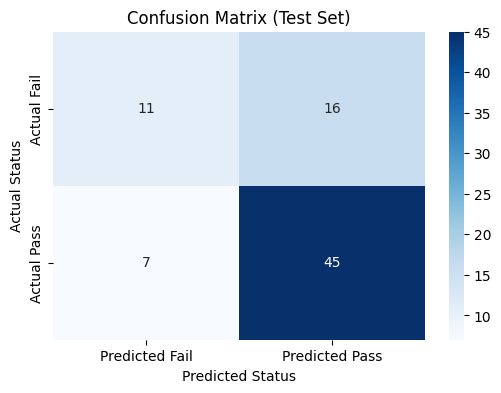

=== Classification Performance Metrics ===
Accuracy:  0.7089
Precision: 0.7377
Recall:    0.8654
F1-Score:  0.7965
ROC-AUC:   0.7286


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# 1. Predict probabilities and convert to binary classes on the test set
y_prob = logit_model.predict(X_test_class_const)
y_pred_class = (y_prob >= 0.5).astype(int)

# 2. Compute Confusion Matrix and Evaluation Metrics
cm = confusion_matrix(y_test_class, y_pred_class)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
roc_auc = roc_auc_score(y_test_class, y_prob)

# 3. Visualize Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

# 4. Print metrics
print("=== Classification Performance Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

In [ ]:
# # 3. Evaluate Logistic Regression model on the test set
# X_test_log = X_test_log.astype(float)
# y_prob = logit_model.predict(X_test_log)
# y_pred_class = (y_prob >= 0.5).astype(int)

# # Compute Confusion Matrix
# cm = confusion_matrix(y_test_log, y_pred_class)

# # Calculate metrics
# accuracy = accuracy_score(y_test_log, y_pred_class)
# precision = precision_score(y_test_log, y_pred_class)
# recall = recall_score(y_test_log, y_pred_class)
# f1 = f1_score(y_test_log, y_pred_class)
# roc_auc = roc_auc_score(y_test_log, y_prob)

# # Display Confusion Matrix
# plt.figure(figsize=(6, 4))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['Predicted Fail', 'Predicted Pass'],
#             yticklabels=['Actual Fail', 'Actual Pass'])
# plt.title('Confusion Matrix (Test Set)')
# plt.ylabel('Actual Status')
# plt.xlabel('Predicted Status')
# plt.show()

# print("=== Classification Performance Metrics ===")
# print(f"Accuracy:  {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1-Score:  {f1:.4f}")
# print(f"ROC-AUC:   {roc_auc:.4f}")

### 10. ROC Curve & Sample Predictions

We generate the diagnostic Receiver Operating Characteristic (ROC) curve and print sample out-of-sample probability predictions to verify the final classifier.

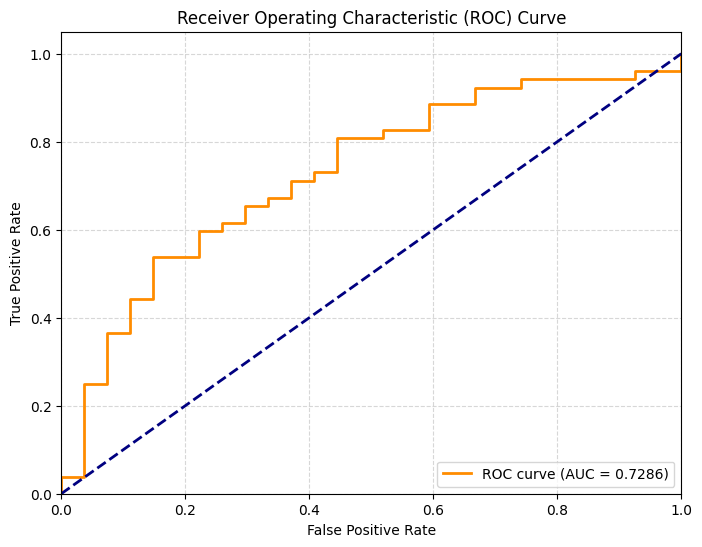

=== Sample Probability Predictions ===
  Actual_Class  Predicted_Probability_Pass Predicted_Class
0         Pass                    0.024742            Fail
1         Pass                    0.428999            Fail
2         Fail                    0.257451            Fail
3         Pass                    0.845787            Pass
4         Fail                    0.584290            Pass


In [ ]:
from sklearn.metrics import roc_curve
import pandas as pd

# 1. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_class, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 2. Generate and display probability predictions for sample test instances
demo_predictions = pd.DataFrame({
    'Actual_Class': pd.Series(y_test_class).iloc[:5].map({1: 'Pass', 0: 'Fail'}).values,
    'Predicted_Probability_Pass': y_prob.iloc[:5].values,
    'Predicted_Class': pd.Series(y_pred_class).iloc[:5].map({1: 'Pass', 0: 'Fail'}).values
})

print("=== Sample Probability Predictions ===")
print(demo_predictions)

In [ ]:
# # 4. Plot ROC Curve
# fpr, tpr, thresholds = roc_curve(y_test_log, y_prob)
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc="lower right")
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.show()

# # 5. Generate and display probability predictions for a few test samples
# demo_predictions = pd.DataFrame({
#     'Actual_Class': y_test_log.iloc[:5].map({1: 'Yes (Passed)', 0: 'No (Failed)'}),
#     'Predicted_Probability_Yes': y_prob.iloc[:5],
#     'Predicted_Class': y_pred_class[:5].map({1: 'Yes (Passed)', 0: 'No (Failed)'})
# })
# print("=== Sample Probability Predictions ===")
# display(demo_predictions)